# Training EfficientNet-B0 on TrashNet

Notebook da duoc lam gon lai theo section ro rang, giu nguyen logic huan luyen mo hinh.


## 1. Imports


In [1]:
import os
import random
import multiprocessing
import shutil
import urllib.request
import zipfile
from contextlib import nullcontext
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import Dataset, random_split
from torch.utils.data.dataloader import DataLoader
from torchvision.utils import make_grid
from PIL import Image


## 2. Training Utilities


In [2]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class ImageClassification(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validating(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'Validation Loss': loss.detach(), 'Validation Accuracy': acc}

    def validating_epoch_final(self, outputs):
        batch_loss = [x['Validation Loss'] for x in outputs]
        epoch_loss = torch.stack(batch_loss).mean()
        batch_accuracy = [x['Validation Accuracy'] for x in outputs]
        epoch_accuracy = torch.stack(batch_accuracy).mean()
        return {'Validation Loss': epoch_loss.item(), 'Validation Accuracy': epoch_accuracy.item()}

    def epoch_final(self, epoch, result):
        print(
            'Epoch [{}], Training Loss: {:.4f}, Validation Loss: {:.4f}, Validation Accuracy: {:.4f}'.format(
                epoch + 1,
                result['Training Loss'],
                result['Validation Loss'],
                result['Validation Accuracy'],
            )
        )


class EarlyStopping:
    def __init__(self, patience=5, verbose=False, restore_best_weights=True):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.restore_best_weights = restore_best_weights
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_weights = model.state_dict().copy()
            if self.verbose:
                print(f'Validation loss improved: {val_loss:.4f}')
        else:
            self.counter += 1
            if self.verbose:
                print(f'Validation loss did not improve: {val_loss:.4f}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_weights is not None:
                    model.load_state_dict(self.best_model_weights)
                    if self.verbose:
                        print('Restored best model weights.')


## 3. Evaluation and Visualization Helpers


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu().clone()
    for channel, mean, std in zip(image, IMAGENET_MEAN, IMAGENET_STD):
        channel.mul_(std).add_(mean)
    return image.clamp(0, 1)


def export_classification_metrics(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        precision = precision_score(class_labels, class_preds, zero_division=0) * 100
        recall = recall_score(class_labels, class_preds, zero_division=0) * 100
        f1 = f1_score(class_labels, class_preds, zero_division=0) * 100

        print(
            f'{class_name}, accuracy: {accuracy:.2f}%, precision: {precision:.2f}%, '
            f'recall: {recall:.2f}%, F1 score: {f1:.2f}%'
        )


def plot_accuracy_per_class(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracies = []
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        accuracies.append(accuracy)

    plt.bar(classes, accuracies)
    plt.xlabel('Classes')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy per Class')
    plt.xticks(rotation=45)
    plt.show()


def plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=classes)

    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix')
    plt.show()


def display_test(image, label):
    print('Label:', dataset.classes[label], '(Class No: ' + str(label) + ')')
    plt.imshow(denormalize_image(image).permute(1, 2, 0))
    plt.show()


def batch_visualization(data):
    for image, labels in data:
        fig, ax = plt.subplots(figsize=(14, 14))
        ax.set_xticks([])
        ax.set_yticks([])
        preview = torch.stack([denormalize_image(img) for img in image[:32]])
        ax.imshow(make_grid(preview, nrow=16).permute(1, 2, 0))
        plt.show()
        break


def predict(image, model):
    xb = move_to_gpu(image.unsqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]


## 4. Dataset Loading and Augmentation


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Dataset directory: /content/trashnet_data/dataset-resized
Environment: Colab/Local
Label: paper (Class No: 3)


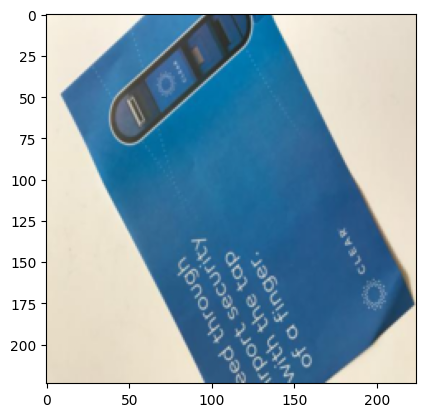

In [4]:
COMPETITION_CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
KAGGLE_WORKING_DIR = Path('/kaggle/working')
COLAB_ROOT = Path('/content')


def running_on_kaggle():
    return Path('/kaggle').exists()


def running_on_colab():
    return COLAB_ROOT.exists() and not running_on_kaggle()


def first_existing_path(candidates, description):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f'Khong tim thay {description}. Da kiem tra: ' + ', '.join(str(path) for path in candidates)
    )


TRAIN_IMAGE_DIR_CANDIDATES = [
    Path('/kaggle/input/image-classification/train/images'),
    Path('/kaggle/input/train/images'),
    Path('/content/train/images'),
    Path.cwd() / 'train' / 'images',
]
TRAIN_CSV_CANDIDATES = [
    Path('/kaggle/input/image-classification/train/train.csv'),
    Path('/kaggle/input/train/train.csv'),
    Path('/content/train/train.csv'),
    Path.cwd() / 'train' / 'train.csv',
]


class CompetitionTrainDataset(Dataset):
    def __init__(self, image_dir, csv_path, transform=None):
        self.image_dir = Path(image_dir)
        self.csv_path = Path(csv_path)
        self.transform = transform
        self.classes = COMPETITION_CLASSES.copy()
        self.dataframe = pd.read_csv(self.csv_path)
        if self.dataframe.empty:
            raise ValueError(f'Khong tim thay sample trong {self.csv_path}')

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.image_dir / row['file_name']
        image = Image.open(image_path).convert('RGB')
        label = int(row['category_id']) - 1
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def resolve_output_path(filename):
    # Ưu tiên kiểm tra Kaggle trước
    if os.path.exists('/kaggle/working'):
        return Path('/kaggle/working') / filename
    # Sau đó mới đến Colab
    if os.path.exists('/content'):
        return Path('/content') / filename
    return Path.cwd() / filename


train_image_dir = first_existing_path(TRAIN_IMAGE_DIR_CANDIDATES, 'thu muc train/images')
train_csv_path = first_existing_path(TRAIN_CSV_CANDIDATES, 'file train.csv')
directory = str(train_image_dir)
global garbage_classes
garbage_classes = COMPETITION_CLASSES.copy()

print(garbage_classes)
print('Train image directory:', directory)
print('Train csv path:', train_csv_path)
print('Environment:', 'Kaggle' if running_on_kaggle() else 'Colab/Local')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

base_dataset = CompetitionTrainDataset(train_image_dir, train_csv_path)
dataset = CompetitionTrainDataset(train_image_dir, train_csv_path, transform=eval_transform)

image, label = random.choice(dataset)
display_test(image, label)


## 5. Data Split and Device Setup


Processing via: cuda
GPU count: 1
num_workers: 2
AMP enabled: True


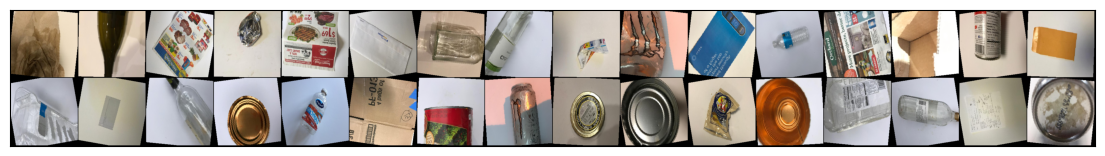

In [5]:
random_seed = 43
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.benchmark = True

train_size = int(0.6 * len(base_dataset))
val_size = int(0.2 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size
train_indices, val_indices, test_indices = random_split(
    range(len(base_dataset)),
    [train_size, val_size, test_size],
)

train_dataset = CompetitionTrainDataset(train_image_dir, train_csv_path, transform=train_transform)
eval_dataset = CompetitionTrainDataset(train_image_dir, train_csv_path, transform=eval_transform)

train_data = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_data = torch.utils.data.Subset(eval_dataset, val_indices.indices)
test_data = torch.utils.data.Subset(eval_dataset, test_indices.indices)

dataset = eval_dataset
batch_size = 64
num_workers = min(4, multiprocessing.cpu_count())
pin_memory = torch.cuda.is_available()
loader_kwargs = {
    'num_workers': num_workers,
    'pin_memory': pin_memory,
}
if num_workers > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2

train = DataLoader(train_data, batch_size, shuffle=True, **loader_kwargs)
validation = DataLoader(val_data, batch_size * 2, shuffle=False, **loader_kwargs)


def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')


def move_to_gpu(data, device):
    if isinstance(data, (list, tuple)):
        return [move_to_gpu(x, device) for x in data]
    return data.to(device, non_blocking=True)


class DataLoad:
    def __init__(self, data, device):
        self.data = data
        self.device = device

    def __iter__(self):
        for batch in self.data:
            yield move_to_gpu(batch, self.device)

    def __len__(self):
        return len(self.data)


device = get_default_device()
amp_enabled = torch.cuda.is_available()
gpu_count = torch.cuda.device_count() if torch.cuda.is_available() else 0
print('Processing via:', device)
print('GPU count:', gpu_count)
print('num_workers:', num_workers)
print('AMP enabled:', amp_enabled)

batch_visualization(train)

train = DataLoad(train, device)
validation = DataLoad(validation, device)


## 6. Model Definition


In [6]:
class EfficientNetModel(ImageClassification):
    def __init__(self):
        super().__init__()
        self.network = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        features = self.network.classifier[1].in_features
        self.network.classifier[1] = nn.Linear(features, len(garbage_classes))

        if torch.cuda.is_available() and torch.cuda.device_count() > 1:
            self.network = nn.DataParallel(self.network)

    def forward(self, image):
        return self.network(image)

    def training_step(self, batch):
        images, labels = batch
        autocast_context = torch.autocast(device_type='cuda', dtype=torch.float16) if amp_enabled else nullcontext()
        with autocast_context:
            out = self(images)
            loss = F.cross_entropy(out, labels)
        return loss

    def epoch_final(self, epoch, result):
        print(
            'Epoch [{}], Training Loss: {:.4f}, Validation Loss: {:.4f}, Validation Accuracy: {:.4f}'.format(
                epoch + 1,
                result['Train Loss'],
                result['Validation Loss'],
                result['Validation Accuracy'],
            )
        )


model = move_to_gpu(EfficientNetModel(), device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]


## 7. Training Loop


In [7]:
@torch.no_grad()
def evaluate(model, validator):
    model.eval()
    outputs = []
    for batch in validator:
        autocast_context = torch.autocast(device_type='cuda', dtype=torch.float16) if amp_enabled else nullcontext()
        with autocast_context:
            outputs.append(model.validating(batch))
    return model.validating_epoch_final(outputs)


def opt(epochs, learning_rate, model, train_loader, validator, opt_func=torch.optim.SGD, patience=5):
    training_history = []
    optimizer = opt_func(model.parameters(), learning_rate)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    for epoch in range(epochs):
        model.train()
        train_loss = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_loss.append(loss.detach())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        result = evaluate(model, validator)
        result['Train Loss'] = torch.stack(train_loss).mean().item()
        model.epoch_final(epoch, result)
        training_history.append(result)

        early_stopping(result['Validation Loss'], model)
        if early_stopping.early_stop:
            print('Early stopping triggered.')
            break

    return training_history


evaluate(model, validation)


{'Validation Loss': 1.7910902500152588,
 'Validation Accuracy': 0.19847624003887177}

## 8. Hyperparameters and Training Execution


In [8]:
epoch = 50
optimizer = torch.optim.Adam
learning_rate = 0.00005
patience = 3
model_history = opt(epoch, learning_rate, model, train, validation, optimizer, patience)


/tmp/ipykernel_732/3405929205.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Epoch [1], Training Loss: 1.7589, Validation Loss: 1.7107, Validation Accuracy: 0.5946
Validation loss improved: 1.7107
Epoch [2], Training Loss: 1.6748, Validation Loss: 1.6160, Validation Accuracy: 0.6773
Validation loss improved: 1.6160
Epoch [3], Training Loss: 1.5812, Validation Loss: 1.5143, Validation Accuracy: 0.7027
Validation loss improved: 1.5143
Epoch [4], Training Loss: 1.4904, Validation Loss: 1.4344, Validation Accuracy: 0.7404
Validation loss improved: 1.4344
Epoch [5], Training Loss: 1.4139, Validation Loss: 1.3743, Validation Accuracy: 0.7760
Validation loss improved: 1.3743
Epoch [6], Training Loss: 1.3566, Validation Loss: 1.3283, Validation Accuracy: 0.7920
Validation loss improved: 1.3283
Epoch [7], Training Loss: 1.3094, Validation Loss: 1.2898, Validation Accuracy: 0.8158
Validation loss improved: 1.2898
Epoch [8], Training Loss: 1.2761, Validation Loss: 1.2601, Validation Accuracy: 0.8415
Validation loss improved: 1.2601
Epoch [9], Training Loss: 1.2395, Valida

## 9. Training Curves and Metrics


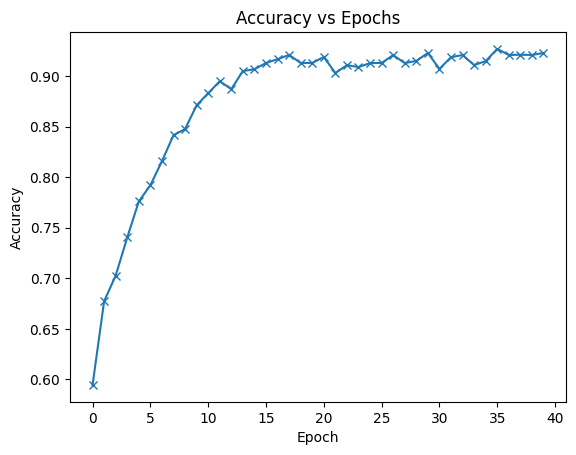

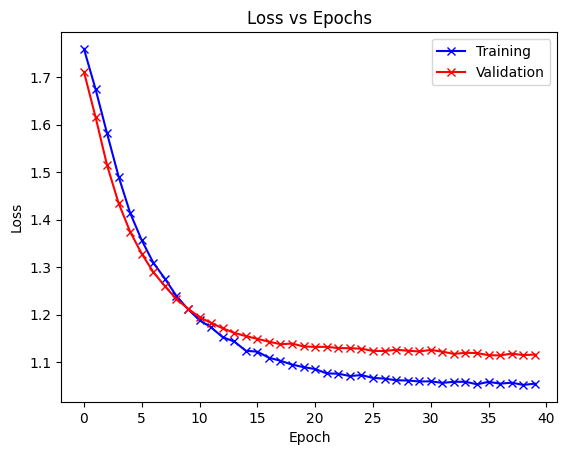

cardboard, accuracy: 99.41%, precision: 98.51%, recall: 97.06%, F1 score: 97.78%
glass, accuracy: 97.23%, precision: 95.08%, recall: 93.55%, F1 score: 94.31%
metal, accuracy: 96.24%, precision: 88.31%, recall: 87.18%, F1 score: 87.74%
paper, accuracy: 98.42%, precision: 98.23%, recall: 94.87%, F1 score: 96.52%
plastic, accuracy: 95.84%, precision: 88.24%, recall: 90.91%, F1 score: 89.55%
trash, accuracy: 97.43%, precision: 62.50%, recall: 78.95%, F1 score: 69.77%


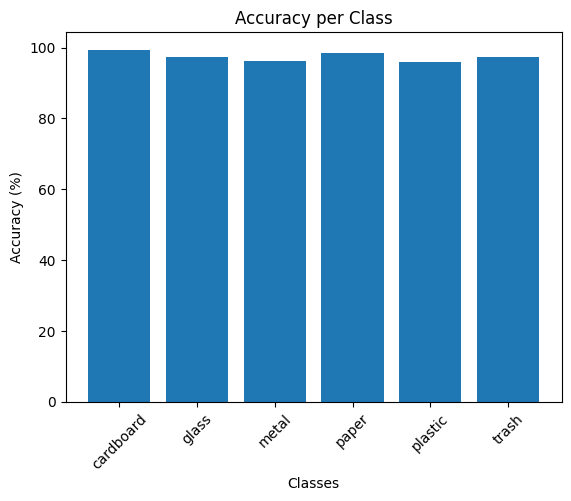

<Figure size 1000x1000 with 0 Axes>

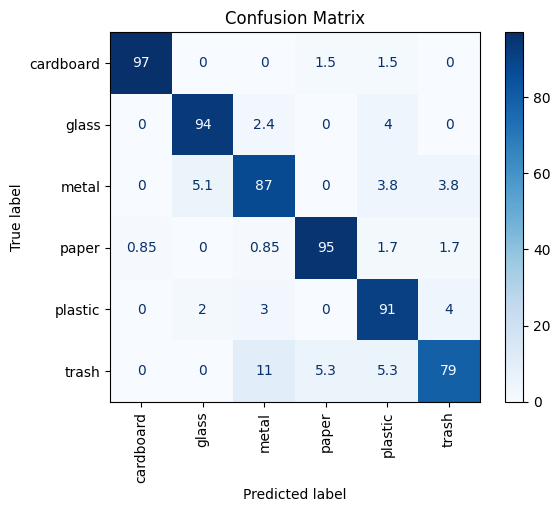

In [9]:
def plot_accuracy(model_history):
    accuracies = [x['Validation Accuracy'] for x in model_history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.show()


def plot_loss(model_history):
    train_loss = [x.get('Train Loss') for x in model_history]
    validation_loss = [x['Validation Loss'] for x in model_history]
    plt.plot(train_loss, '-bx')
    plt.plot(validation_loss, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs Epochs')
    plt.show()

# Filter out '.DS_Store' from garbage_classes as it's not a real class in the dataset.
# This resolves the ValueError in plot_confusion_matrix due to label mismatch
# and cleans up metrics for other functions.
filtered_garbage_classes = [c for c in garbage_classes if c != '.DS_Store']

def export_classification_metrics(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Note: The mapping of `i` to class name assumes `classes` is ordered
    # consistently with how `ImageFolder` assigns numerical labels. If not,
    # per-class metrics may be mislabeled. This fix primarily addresses the `.DS_Store` issue.
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        precision = precision_score(class_labels, class_preds, zero_division=0) * 100
        recall = recall_score(class_labels, class_preds, zero_division=0) * 100
        f1 = f1_score(class_labels, class_preds, zero_division=0) * 100

        print(
            f'{class_name}, accuracy: {accuracy:.2f}%, precision: {precision:.2f}%, '
            f'recall: {recall:.2f}%, F1 score: {f1:.2f}%'
        )


def plot_accuracy_per_class(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracies = []
    # Note: Similar to export_classification_metrics, label ordering matters here.
    for i, class_name in enumerate(classes):
        class_labels = [1 if label == i else 0 for label in all_labels]
        class_preds = [1 if pred == i else 0 for pred in all_preds]

        accuracy = accuracy_score(class_labels, class_preds) * 100
        accuracies.append(accuracy)

    plt.bar(classes, accuracies)
    plt.xlabel('Classes')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy per Class')
    plt.xticks(rotation=45)
    plt.show()


def plot_confusion_matrix(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch
            images = move_to_gpu(images, device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    # Use the filtered classes for display labels to match the confusion matrix dimensions.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=classes)

    plt.figure(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix')
    plt.show()


plot_accuracy(model_history)
plot_loss(model_history)
export_classification_metrics(model, validation, filtered_garbage_classes)
plot_accuracy_per_class(model, validation, filtered_garbage_classes)
plot_confusion_matrix(model, validation, filtered_garbage_classes)

## 10. Sample Predictions


Testing No.1 - Class: paper , Predicted Class: paper


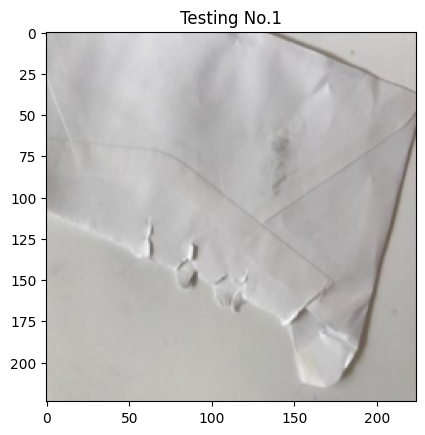

Testing No.2 - Class: cardboard , Predicted Class: cardboard


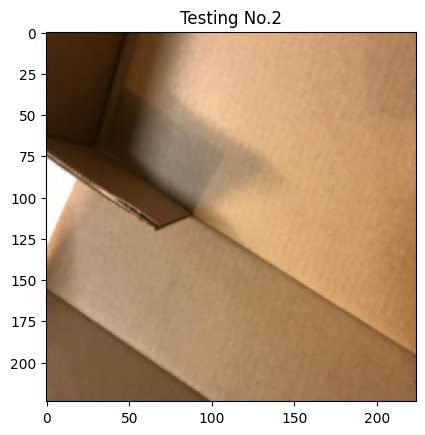

Testing No.3 - Class: paper , Predicted Class: paper


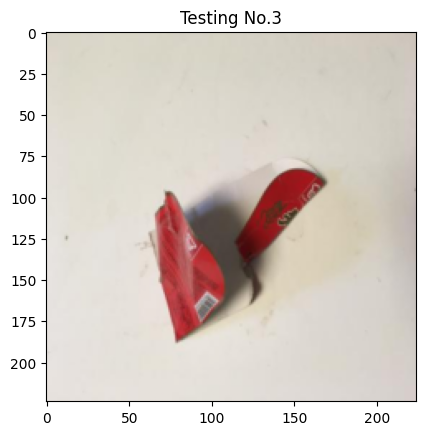

In [ ]:
for idx in range(1, 4):
    img, label = random.choice(dataset)
    plt.imshow(denormalize_image(img).permute(1, 2, 0))
    print(f'Testing No.{idx} - Class:', dataset.classes[label], ', Predicted Class:', predict(img, model))
    plt.title(f'Testing No.{idx}')
    plt.show()


## 11. Save Model


In [10]:
# 1. Xác định đường dẫn lưu file
FILE = resolve_output_path('EfficientNetB0Model.pth')

# 2. Lấy mô hình gốc (bóc tách khỏi DataParallel nếu có)
model_to_save = model.module if hasattr(model, 'module') else model

# 3. Lưu weights (state_dict) - Đây là cách an toàn và phổ biến nhất
torch.save(model_to_save.state_dict(), FILE)

print(f'✅ Đã lưu mô hình thành công tại: {FILE}')

✅ Đã lưu mô hình thành công tại: /content/EfficientNetB0Model.pth


## 12. Private Test Inference and Submission

Section nay load lai trong so da train xong va chay suy luan tren folder private test cho ca Kaggle va Google Colab.


### Gắn Google Drive để truy cập dữ liệu

Để truy cập file `images.zip` từ Google Drive, bạn cần gắn Drive của mình. Vui lòng chạy cell bên dưới và cấp quyền truy cập khi được yêu cầu.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive đã được gắn thành công.')

Mounted at /content/drive
Google Drive đã được gắn thành công.


### Giải nén file `images.zip` từ Google Drive

Bây giờ bạn đã gắn Google Drive, hãy cung cấp đường dẫn đầy đủ đến file `images.zip` của bạn trong cell bên dưới. **Đảm bảo rằng đường dẫn là chính xác**, sau đó chạy cell để giải nén file vào thư mục `/content/images`.

In [14]:
import zipfile
from pathlib import Path
import shutil

# --- THAY ĐỔI ĐƯỜNG DẪN NÀY ĐẾN FILE images.zip CỦA BẠN TRÊN GOOGLE DRIVE ---
# Ví dụ: '/content/drive/MyDrive/my_data/images.zip'
user_test_zip_path_from_drive = Path('/content/drive/MyDrive/images.zip') # <--- THAY ĐỔI TẠI ĐÂY
# -----------------------------------------------------------------------

private_test_output_dir = Path('/content/images')

# Create the output directory if it doesn't exist and clear its contents if it does
if private_test_output_dir.exists():
    shutil.rmtree(private_test_output_dir) # Clear existing directory (e.g., dummy data)
private_test_output_dir.mkdir(parents=True, exist_ok=True)

# Unzip the file provided by the user
if user_test_zip_path_from_drive.exists():
    with zipfile.ZipFile(user_test_zip_path_from_drive, 'r') as zip_ref:
        zip_ref.extractall(private_test_output_dir)
    print(f'Đã giải nén `{user_test_zip_path_from_drive}` vào `{private_test_output_dir}`.')
    print(f'Nội dung của thư mục `{private_test_output_dir}`:')
    for item in private_test_output_dir.iterdir():
        print(item.name)
else:
    print(f'File zip `{user_test_zip_path_from_drive}` không tìm thấy. Vui lòng kiểm tra lại đường dẫn trên Google Drive.')

Đã giải nén `/content/drive/MyDrive/images.zip` vào `/content/images`.
Nội dung của thư mục `/content/images`:
images


### (Tùy chọn) Tạo thư mục và file ảnh dummy cho private test

Nếu bạn chưa có file `images.zip` của riêng mình, bạn có thể chạy các cell bên dưới để tạo một thư mục tạm thời chứa một số ảnh dummy và nén lại thành file `private_test.zip`. Sau đó, chúng ta sẽ giải nén file này vào thư mục `/content/images` để mô phỏng dữ liệu test thực tế. **Lưu ý:** Nếu bạn đã giải nén `images.zip` ở bước trước, việc chạy các cell này sẽ ghi đè lên dữ liệu đó.

### Chuẩn bị dữ liệu Private Test từ file `images.zip`

Nếu bạn có file `images.zip` chứa dữ liệu private test của mình, vui lòng **tải lên file này vào môi trường Colab** (ví dụ: kéo thả vào thanh bên trái hoặc sử dụng biểu tượng thư mục) trước khi chạy cell tiếp theo. Sau đó, cell bên dưới sẽ giải nén nội dung của `images.zip` vào thư mục `/content/images`.

In [12]:
import zipfile
from pathlib import Path
import shutil

user_test_zip_path = Path('/content/images.zip')
private_test_output_dir = Path('/content/images')

# Create the output directory if it doesn't exist and clear its contents if it does
if private_test_output_dir.exists():
    shutil.rmtree(private_test_output_dir) # Clear existing directory (e.g., dummy data)
private_test_output_dir.mkdir(parents=True, exist_ok=True)

# Unzip the file provided by the user
if user_test_zip_path.exists():
    with zipfile.ZipFile(user_test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(private_test_output_dir)
    print(f'Đã giải nén `{user_test_zip_path}` vào `{private_test_output_dir}`.')
    print(f'Nội dung của thư mục `{private_test_output_dir}`:')
    for item in private_test_output_dir.iterdir():
        print(item.name)
else:
    print(f'File zip `{user_test_zip_path}` không tìm thấy. Vui lòng đảm bảo bạn đã tải lên file `images.zip` vào `/content/`.')


File zip `/content/images.zip` không tìm thấy. Vui lòng đảm bảo bạn đã tải lên file `images.zip` vào `/content/`.


### (Tùy chọn) Tạo thư mục và file ảnh dummy cho private test

Nếu bạn chưa có file `images.zip` của riêng mình, bạn có thể chạy các cell bên dưới để tạo một thư mục tạm thời chứa một số ảnh dummy và nén lại thành file `private_test.zip`. Sau đó, chúng ta sẽ giải nén file này vào thư mục `/content/images` để mô phỏng dữ liệu test thực tế. **Lưu ý:** Nếu bạn đã giải nén `images.zip` ở bước trước, việc chạy các cell này sẽ ghi đè lên dữ liệu đó.

In [17]:
PRIVATE_TEST_DIR_CANDIDATES = [
    Path('/kaggle/input/image-classification/images'),
    Path('/content/images/images'), # Added this path
    Path('/content/images'),
    Path.cwd() / 'images',
]

MODEL_PATH_CANDIDATES = [
    Path('/kaggle/working/EfficientNetB0Model.pth'),
    Path('/content/EfficientNetB0Model.pth'),
    resolve_output_path('EfficientNetB0Model.pth'),
]

def first_existing_path(candidates, description):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f'Khong tim thay {description}. Da kiem tra: ' + ', '.join(str(path) for path in candidates)
    )

private_test_dir = first_existing_path(PRIVATE_TEST_DIR_CANDIDATES, 'thu muc private test')
model_weights_path = first_existing_path(MODEL_PATH_CANDIDATES, 'file trong so mo hinh')
submission_path = resolve_output_path('submission.csv')

print('Private test dir:', private_test_dir)
print('Model weights path:', model_weights_path)
print('Submission path:', submission_path)


Private test dir: /content/images/images
Model weights path: /content/EfficientNetB0Model.pth
Submission path: /content/submission.csv


### Kiểm tra nội dung của thư mục Private Test

Để xác định lý do tại sao không tìm thấy ảnh, chúng ta sẽ liệt kê nội dung của thư mục `private_test_dir` (`/content/images/images`) và tìm kiếm các file ảnh một cách đệ quy.

In [ ]:
import os

print(f"Nội dung của thư mục private_test_dir ({private_test_dir}):")

found_image_files = []

if not private_test_dir.exists():
    print(f"Thư mục {private_test_dir} không tồn tại.")
elif not os.listdir(private_test_dir):
    print(f"Thư mục {private_test_dir} rỗng.")
else:
    for root, dirs, files in os.walk(private_test_dir):
        # Print subdirectories and files found at each level
        level = root.replace(str(private_test_dir), '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for d in dirs:
            print(f'{subindent}{d}/')
        for f in files:
            print(f'{subindent}{f}')
            # Check if it's an image file
            if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
                found_image_files.append(Path(root) / f)


if found_image_files:
    print(f"\nĐã tìm thấy {len(found_image_files)} file ảnh trong {private_test_dir} (hoặc các thư mục con).")
    print("Các đường dẫn ảnh mẫu:")
    for i, img_path in enumerate(found_image_files[:5]): # Print up to 5 sample paths
        print(f"- {img_path}")

    # Update private_test_dir to the common parent directory if images are deeply nested
    # This part is complex and might need user input, but for now, we just list found files.
    # The issue is likely that private_test_dir should be the parent of where the images are.
    # For instance, if found_image_files contains /content/images/images/test_set/img1.jpg
    # then private_test_dir might need to be /content/images/images/test_set

    # Check if all found images share a common direct parent that is a subdirectory of private_test_dir
    if len(found_image_files) > 0: # Check again in case of filtering issues
        first_image_parent = found_image_files[0].parent
        all_in_same_subdir = True
        for img_path in found_image_files:
            if img_path.parent != first_image_parent:
                all_in_same_subdir = False
                break

        if all_in_same_subdir and first_image_parent != private_test_dir:
            # If all images are in one subdirectory, update private_test_dir to point to it
            print(f"\nTất cả các file ảnh dường như nằm trong cùng một thư mục con: {first_image_parent}")
            print(f"Cập nhật `private_test_dir` thành: {first_image_parent}")
            private_test_dir = first_image_parent

else:
    print("\nKhông tìm thấy file ảnh nào có định dạng .jpg, .jpeg, .png, .webp trong private_test_dir hoặc các thư mục con của nó.")
    print("Vui lòng kiểm tra lại cấu trúc file `images.zip` hoặc đường dẫn đến file zip.")


In [18]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
class_to_category_id = {class_name: index + 1 for index, class_name in enumerate(class_names)}

inference_model = EfficientNetModel().to(device)
state_dict = torch.load(model_weights_path, map_location=device)
inference_model.load_state_dict(state_dict)
inference_model.eval()

submission_rows = []
image_paths = sorted([
    path for path in private_test_dir.iterdir()
    if path.is_file() and path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}
])

with torch.no_grad():
    for image_path in image_paths:
        image = Image.open(image_path).convert('RGB')
        tensor = eval_transform(image).unsqueeze(0).to(device)

        outputs = inference_model(tensor)
        _, preds = torch.max(outputs, dim=1)
        predicted_class = class_names[preds[0].item()]

        submission_rows.append({
            'file_name': image_path.name,
            'category_id': class_to_category_id[predicted_class],
        })

submission_df = pd.DataFrame(submission_rows).sort_values('file_name').reset_index(drop=True)
submission_df.to_csv(submission_path, index=False)

print(f'Da tao file submission tai: {submission_path}')
submission_df.head(10)


Da tao file submission tai: /content/submission.csv


,file_name,category_id
0,00002.jpg,2
1,00004.jpg,3
2,00006.jpg,1
3,00007.jpg,5
4,00010.jpg,5
5,00014.jpg,4
6,00022.jpg,3
7,00023.jpg,1
8,00024.jpg,4
9,00025.jpg,2
